In [2]:
%pip install imbalanced-learn

   ---------------------------------------- 0.0/11.1 MB ? eta -:--:--
   --- ------------------------------------ 1.0/11.1 MB 6.2 MB/s eta 0:00:02
   ------ --------------------------------- 1.8/11.1 MB 4.3 MB/s eta 0:00:03
   ------- -------------------------------- 2.1/11.1 MB 3.4 MB/s eta 0:00:03
   ---------- ----------------------------- 2.9/11.1 MB 3.7 MB/s eta 0:00:03
   ------------- -------------------------- 3.7/11.1 MB 3.5 MB/s eta 0:00:03
   --------------- ------------------------ 4.2/11.1 MB 3.6 MB/s eta 0:00:02
   ------------------ --------------------- 5.2/11.1 MB 3.5 MB/s eta 0:00:02
   ------------------ --------------------- 5.2/11.1 MB 3.5 MB/s eta 0:00:02
   ------------------ --------------------- 5.2/11.1 MB 3.5 MB/s eta 0:00:02
   ------------------ --------------------- 5.2/11.1 MB 3.5 MB/s eta 0:00:02
   -------------------- ------------------- 5.8/11.1 MB 2.4 MB/s eta 0:00:03
   ---------------------- ----------------- 6.3/11.1 MB 2.5 MB/s eta 0:00:02
   ---

  You can safely remove it manually.

[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Data Handling
import pandas as pd
import numpy as np

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Imbalance Handling
from imblearn.over_sampling import SMOTE

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [4]:
df = pd.read_csv("dataset/credit_risk_cleaned.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
X = df.drop('Class', axis=1)

y = df['Class']

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (283726, 30)
Target Shape: (283726,)


In [6]:
y.value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

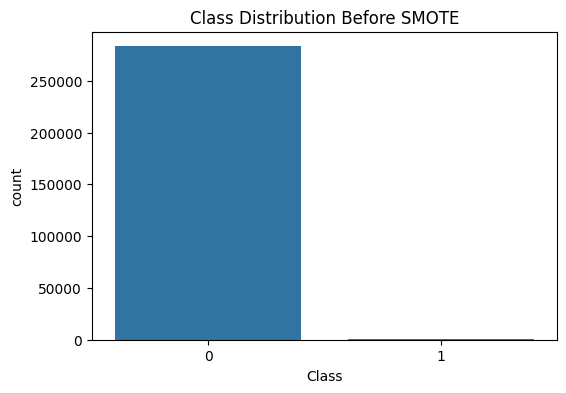

In [7]:
plt.figure(figsize=(6,4))

sns.countplot(x=y)

plt.title("Class Distribution Before SMOTE")

plt.show()

In [8]:
scaler = StandardScaler()

X['Amount'] = scaler.fit_transform(X[['Amount']])

X['Time'] = scaler.fit_transform(X[['Time']])

X.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,-1.996823,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.244200
1,-1.996823,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.342584
2,-1.996802,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.158900
3,-1.996802,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.139886
4,-1.996781,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.073813


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)

X_train Shape: (226980, 30)
X_test Shape: (56746, 30)


In [10]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())

print("\nAfter SMOTE:")

print(y_train_smote.value_counts())

Before SMOTE: Class
0    226602
1       378
Name: count, dtype: int64

After SMOTE:
Class
0    226602
1    226602
Name: count, dtype: int64


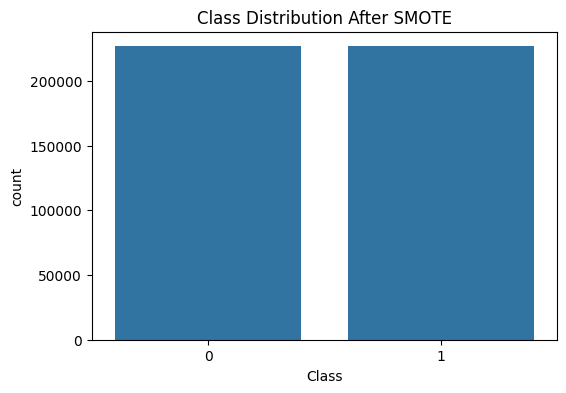

In [11]:
plt.figure(figsize=(6,4))

sns.countplot(x=y_train_smote)

plt.title("Class Distribution After SMOTE")

plt.show()

In [12]:
processed_train = pd.concat(
    [pd.DataFrame(X_train_smote), pd.DataFrame(y_train_smote)],
    axis=1
)

processed_train.to_csv(
    "dataset/processed_fraud_train_smote.csv",
    index=False
)

In [13]:
import joblib

joblib.dump(scaler, "models/scaler_fraud.pkl")

['models/scaler_fraud.pkl']